In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import time 
from tqdm import tqdm

import jax
import jax.numpy as jnp
    
from dataclasses import dataclass
#jax.config.update("jax_disable_jit", True)

import pickle

In [2]:
import nambu_class as nmb
import system_state as sys_state
import run_computation as comp
import custom_optimizer as copt
import Usadel_methods as usadel


#jax.config.update("jax_disable_jit", True)


In [3]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1500
# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
sigma_scatterings = {'Phonon': 0.1} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)

print(my_usadel._get_BCS_coupling())
print(my_usadel.eta)

0.24423933
0.03525404


In [4]:
def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

def save_data(data, filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data, output)
        
def load_data(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data

def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]

        return title, data[:, 0], data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

        return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]



def save_two_column_text(data, filename):                                                         
      """                                                                                           
      Save 2-column data to a text file with whitespace separation.                                 
                                                                                                    
      Parameters                                                                                    
      ----------                                                                                    
      data : array-like, shape (N, 2)                                                               
          Two-column data to save. Can be a list of tuples, 2D numpy array, etc.                    
      filename : str                                                                                
          Path to the output text file.                                                             
                                                                                                    
      Examples                                                                                      
      --------                                                                                      
      >>> data = [[1.0, 2.5], [3.0, 4.2], [5.0, 6.8]]                                               
      >>> save_two_column_text(data, 'output.txt')                                                  
      """                                                                                           
      data = np.asarray(data)                                                                       
      if data.ndim != 2 or data.shape[1] != 2:                                                      
          raise ValueError(f"Data must be 2-column array, got shape {data.shape}")                  
                                                                                                    
      np.savetxt(filename, data, fmt='%.18e', delimiter=' ')                                        
                               

def read_two_column_text(filename):                                                               
      """                                                                                           
      Read 2-column data from a text file with whitespace separation.                               
                                                                                                    
      Parameters                                                                                    
      ----------                                                                                    
      filename : str                                                                                
          Path to the input text file.                                                              
                                                                                                    
      Returns                                                                                       
      -------                                                                                       
      data : numpy.ndarray, shape (N, 2)                                                            
          Two-column data array.                                                                    
                                                                                                    
      Examples                                                                                      
      --------                                                                                      
      >>> data = read_two_column_text('output.txt')                                                 
      >>> col1, col2 = data[:, 0], data[:, 1]                                                       
      """                                                                                           
      data = np.loadtxt(filename)                                                                   
      if data.ndim == 1:  # Single row case                                                         
          data = data.reshape(1, -1)                                                                
      if data.shape[1] != 2:                                                                        
          raise ValueError(f"File must contain exactly 2 columns, got {data.shape[1]}")             
                                                                                                    
      return data  


### Run $\Delta(Q,T)$ and $J(Q,T)$ curves

In [5]:
temp_list = jnp.linspace(0.05, 1.2, 1)
Q_list = jnp.linspace(0.0,0.7,30)

In [ ]:
gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

  3%|▎         | 1/30 [00:01<00:47,  1.62s/it]

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython.message.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/checkrc.pxd", line 13, in zmq.backend.cython.checkrc._check_rc
KeyboardInterrupt: 
  7%|▋         | 2/30 [00:05<01:28,  3.17s/it]

[1.0194782e+00 1.0182583e+00 1.0146104e+00 1.0084831e+00 9.9967992e-01
 9.8822469e-01 9.7388995e-01 9.5645159e-01 9.3561280e-01 9.1098756e-01
 8.8206828e-01 8.4818584e-01 8.0841601e-01 7.6147592e-01 7.0546979e-01
 6.3741773e-01 5.5170709e-01 4.3733674e-01 2.5568447e-01 1.1918618e-05
 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05
 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05 1.1918618e-05]


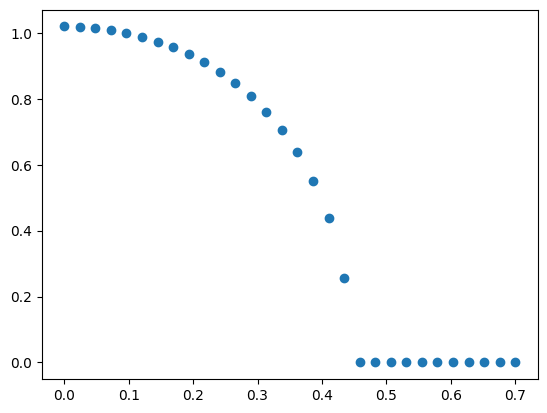

[ 0.0000000e+00  3.6683369e-01  7.2859204e-01  1.0801491e+00
  1.4159929e+00  1.7309123e+00  2.0190556e+00  2.2743301e+00
  2.4901850e+00  2.6595218e+00  2.7745543e+00  2.8267066e+00
  2.8063164e+00  2.7025940e+00  2.5032451e+00  2.1942687e+00
  1.7576898e+00  1.1763749e+00  4.2683154e-01 -2.6006232e-05
 -2.7374981e-05 -2.8743731e-05 -3.0112478e-05 -3.1481228e-05
 -3.2849977e-05 -3.4218727e-05 -3.5587473e-05 -3.6956226e-05
 -3.8324975e-05 -3.9693721e-05]


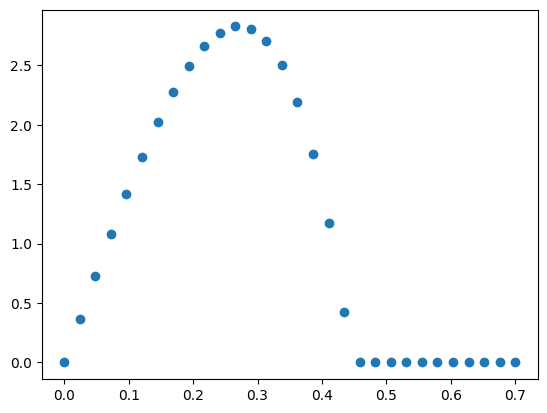

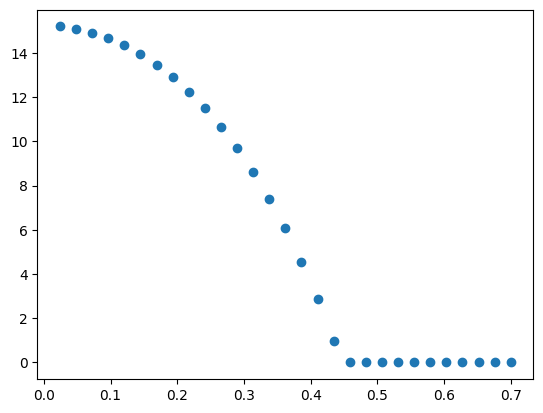

In [11]:
#print(gap_list)
#plt.scatter(temp_list,gap_list)
plt.scatter(Q_list,gap_list.T)
print(gap_list[0])
plt.show()
print(current_list[0])
plt.scatter(Q_list,current_list[0].real)
plt.show()
plt.scatter(Q_list,current_list[0].real/Q_list)
#plt.plot(Q_list,np.abs(gap_list.T[0])* (1 - Q_list**2/gap_list.T[0]/2) ** (3/2), 'k--')

In [ ]:
x

### Run $Q(t)$ pulse simulation for weak pulses 

In [ ]:
current_function = lambda x: jnp.exp(-x**2) * 0.1
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(0.3, current_function=current_function, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)

In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

plt.plot(times, jnp.gradient(q_vs_time,times))

plt.show()

plt.plot(times, jnp.gradient(q_vs_time,times)* 10 + current_vs_time)
plt.plot(times, pulse_in)

## Run procedure for actual data

In [39]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 500}
sigma_scatterings = {'Phonon': 0.2} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5

my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)
print('eta/T_c is', my_usadel.eta)
print('Cutoff is', my_usadel.cutoff)
#TODO: run vs T for different Q values, T-Q plane



eta/T_c is 0.052916314
Cutoff is 52.916313


### Find current scaling factor

In [40]:
Q_list = jnp.sort(jnp.append(jnp.linspace(0.0,0.7,10),jnp.linspace(0.25,0.45,10)))

In [41]:
gap_list, current_list = comp.calculate_equilibrium([run_temperature], grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

100%|██████████| 20/20 [02:50<00:00,  8.51s/it]


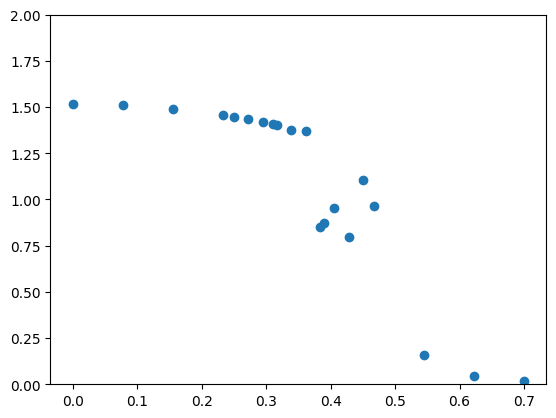

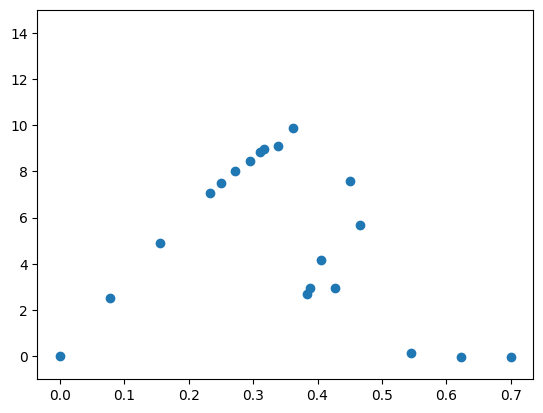

1.5174296


In [43]:
plt.scatter(Q_list,gap_list.T)
plt.ylim(0,2)
plt.show()
plt.scatter(Q_list,current_list[0].real)
plt.ylim(-1,15) 
plt.show()
print(jnp.max(gap_list.T[:3]))

In [11]:
CURRENT_MAXIMUM = jnp.max(current_list[0])
print(CURRENT_MAXIMUM)


9.268737


In [ ]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 500}
sigma_scatterings = {'Phonon': 0.3} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5


my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)
print('eta/T_c is', my_usadel.eta)
print('Cutoff is', my_usadel.cutoff)
#TODO: run vs T for different Q values, T-Q plane



### Define the current relative to that scaling factor

In [ ]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'z_t/R_n': 50/130}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
#sigma_scatterings = {'Elastic': 10.0, 'Dynes': 5.0} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

run_temperature = 0.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

In [ ]:
Q_list = jnp.linspace(0.0,0.7,30)

In [ ]:
gap_list, current_list = comp.calculate_equilibrium([run_temperature], grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None,  Q_list = Q_list)

In [ ]:
plt.plot(Q_list,gap_list.T)
plt.show()
plt.plot(Q_list,current_list[0].real)
plt.show()

### Run Individual Q(t) scans

In [ ]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)

In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

In [ ]:
crt_pulse = lambda x: 1.0 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)


In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

In [ ]:
crt_pulse = lambda x: 3.0 * current_function_gaussian(x)

times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = None)


In [ ]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

#TODO: kick it with a random seed on top of last solution

print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

## Test Normal state resistivity

In [12]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.1} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 1.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [14]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 99/99 [06:48<00:00,  4.13s/it]


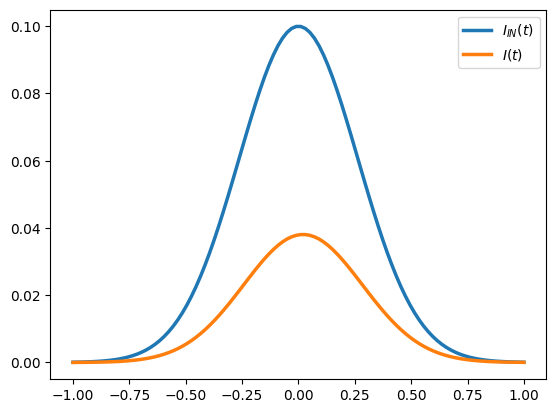

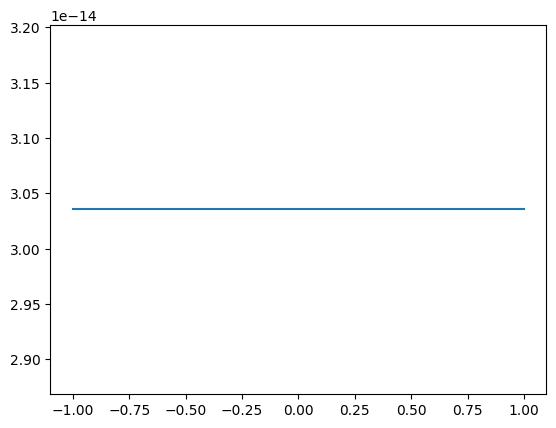

Transmitivity is 0.38066158


In [15]:
plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

## Testing superfluid response with normal fluid (low T)

In [ ]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.3} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5

#* T_c in kelvin
T_c = 15.5
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [13]:
crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)

100%|██████████| 99/99 [07:34<00:00,  4.59s/it]


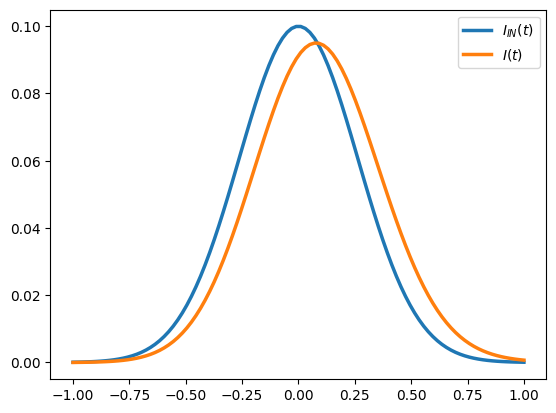

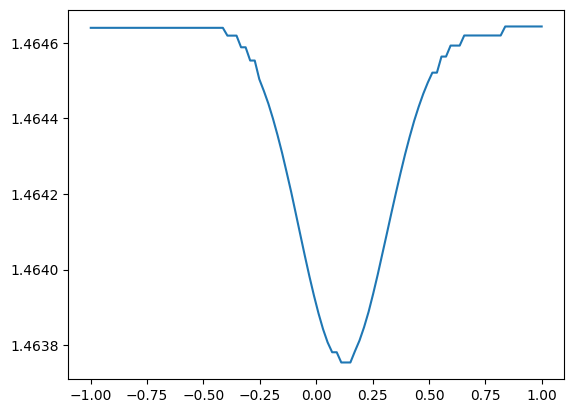

Transmitivity is 0.9506345


In [14]:
#* Without normal fluid response it looks like this

plt.plot(times , pulse_in, label = r'$I_{IN}(t)$', linewidth = 2.5) 
plt.plot(times, current_vs_time, label = r'$I(t)$', linewidth = 2.5)
plt.legend()
plt.show()

plt.plot(times, gap_vs_time)

plt.show()

crt_pulse = lambda x: 0.1 * current_function_gaussian(x)
print('Transmitivity is', jnp.max(current_vs_time)/jnp.max(pulse_in))

## Run the full parameter scan for T = 0.5T_c

In [23]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1000

# Define the fine grid
fine_nw = 200
fine_cutoff = 1.0* usadel.UsadelEvolution.get_bcs_ratio()

fine_nw = nw
fine_cutoff = cutoff

grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 1.0, 'time_sampling': 100}
system_parameters = {'critical_temperature': 1.0, 'current_maximum': 9.268737, 'temperature': 0.5, 'z_t/R_n': 50/160}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 100}
sigma_scatterings = {'Phonon': 0.3} # {'Dynes': 0.0, 'Elastic': 0.0}
#sigma_scatterings = None

run_temperature = 0.5

#* T_c in kelvin
T_c = 15.5 
#* write the current pulse in units of T_C. 
#*  FWHM = 1ps in 
t_pulse = 0.020 * T_c
print('T pulse is ', t_pulse)
current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 

T pulse is  0.31


In [24]:
current_amplitudes = np.linspace(0.1, 6, 10)
times_out = []
pulse_in_out = []
current_vs_time_out = []
gap_vs_time_out = []
q_vs_time_out = []
transmitivity_out = []
current_inside_out = []

for amp in current_amplitudes:
    crt_pulse = lambda x: amp * current_function_gaussian(x)
    times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
    times_out += [times]
    pulse_in_out += [pulse_in]
    current_vs_time_out += [current_vs_time]
    gap_vs_time_out += [gap_vs_time]
    q_vs_time_out += [q_vs_time]
    transmitivity_out += [jnp.max(current_vs_time)/jnp.max(pulse_in)]
    current_inside_out += [jnp.max(current_vs_time)]

100%|██████████| 99/99 [05:08<00:00,  3.12s/it]


In [25]:
def save_data(data, filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data, output)
        
def load_data(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data


def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

    return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]


In [26]:
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')


(99, 4)


In [27]:
normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3


(99, 4)


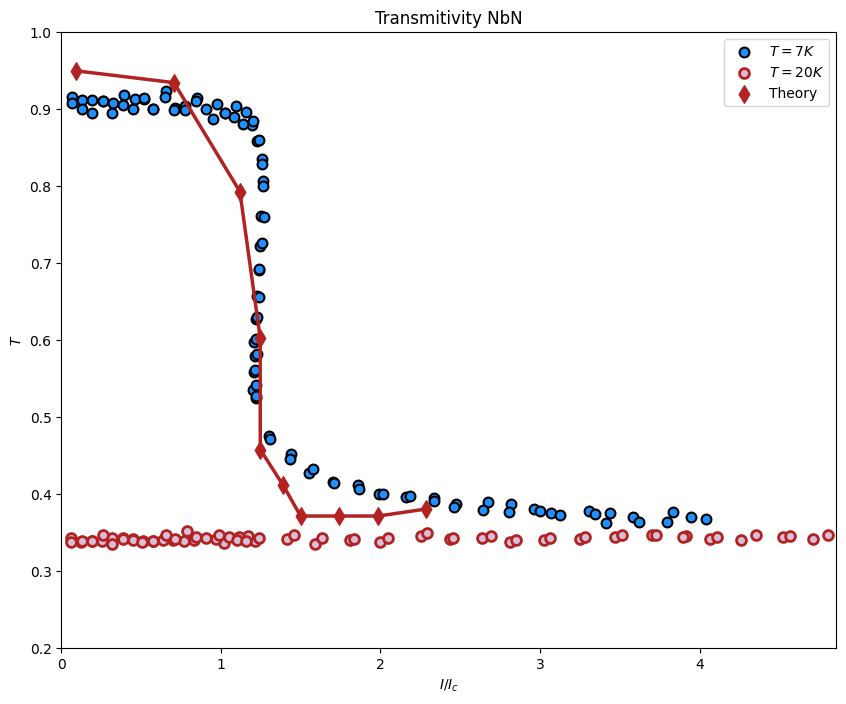

In [28]:
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

I_c = 35
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,170/I_c)



plt.scatter(current_inside_out, np.array(current_inside_out)/current_amplitudes, marker = 'd', color = 'firebrick', s = 80, label = r'Theory')
plt.plot(current_inside_out, np.array(current_inside_out)/current_amplitudes, color = 'firebrick', linewidth = 2.5)
plt.xlabel(r'$I/I_c$')
plt.ylabel(r'$T$')
plt.legend()

plt.savefig('Dirty supercondutor - medium eta - medium phonons.png', dpi = 300)

(99, 4)


/tmp/ipykernel_26499/862381141.py:15: RuntimeWarning: invalid value encountered in divide
  axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)


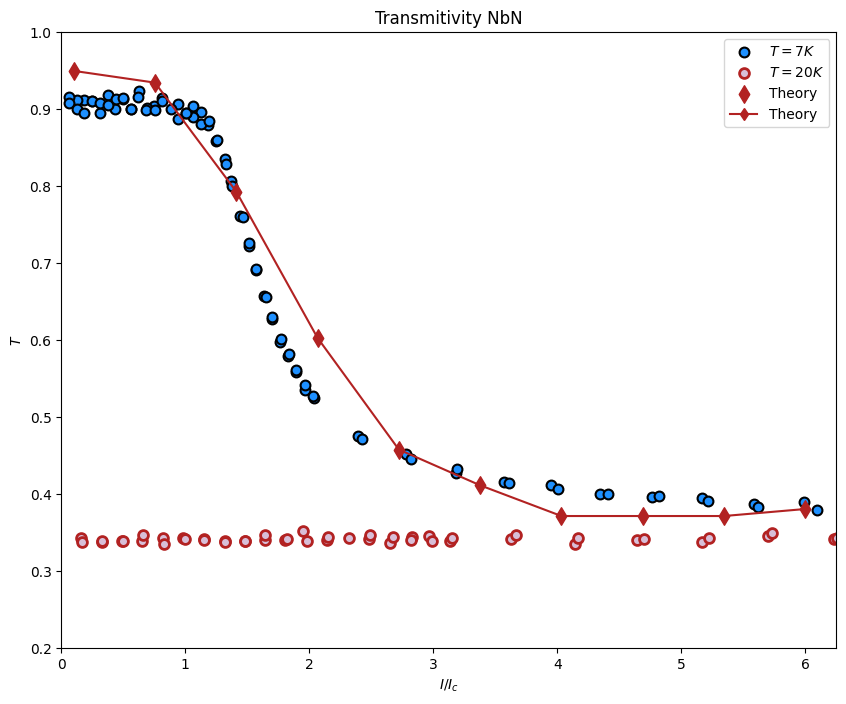

In [31]:
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

I_c = 40
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c/sc_data_y, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)


plt.scatter(current_amplitudes, np.array(current_inside_out)/current_amplitudes, marker = 'd', color = 'firebrick', s = 80, label = r'Theory')
plt.plot(current_amplitudes, np.array(current_inside_out)/current_amplitudes, marker = 'd', color = 'firebrick', label = r'Theory')

plt.xlabel(r'$I/I_c$')
plt.ylabel(r'$T$')
plt.legend()

#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

In [ ]:
#plot delta * dtQ/(Q) and delta_max * dtQ/Q

## Run a full procedure

In [4]:
title, data_x, data_y = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/Rect_pulse_in.dat')
plt.scatter(data_x, data_y/(37.3 * 8/10))

GLOBAL_DATA_X = data_x
GLOBAL_DATA_Y = data_y

def linear_interpolate(data_x: list[float], data_y: list[float], x: list[float]) -> list[float]:
    """
    Linear interpolator that computes f(x) for a list of query points.
 
    Args:
        data_x: Known x-coordinates (must be sorted in ascending order, no duplicates).
        data_y: Known y-coordinates corresponding to data_x (same length).
        x:      Query points at which to interpolate (or extrapolate).
 
    Returns:
        List of interpolated (or linearly extrapolated) values for each point in x.
 
    Raises:
        ValueError: If data_x and data_y have different lengths or fewer than 2 points.
    """
    if len(data_x) != len(data_y):
        raise ValueError("data_x and data_y must have the same length.")
    if len(data_x) < 2:
        raise ValueError("At least two data points are required for interpolation.")
 
    def _interpolate_single(xi: float) -> float:
        # Find the segment that brackets xi using binary search
        lo, hi = 0, len(data_x) - 1
 
        # Extrapolate with the first/last segment if xi is out of range
        if xi <= data_x[lo]:
            return 0
            lo, hi = 0, 1
        elif xi >= data_x[hi]:
            return 0 
            lo, hi = len(data_x) - 2, len(data_x) - 1
        else:
            # Binary search for the bracketing interval
            while hi - lo > 1:
                mid = (lo + hi) // 2
                if data_x[mid] <= xi:
                    lo = mid
                else:
                    hi = mid
 
        # Linear interpolation formula: y = y0 + (y1 - y0) * (xi - x0) / (x1 - x0)
        x0, x1 = data_x[lo], data_x[hi]
        y0, y1 = data_y[lo], data_y[hi]
        t = (xi - x0) / (x1 - x0)
        return y0 + (y1 - y0) * t
 
    return [_interpolate_single(xi) for xi in x]

incoming_pulse_rect = lambda t : linear_interpolate(data_x, data_y/(37.3 * 8/10), t)

plt.plot(np.linspace(-5, 30, 1000), np.array(incoming_pulse_rect(np.linspace(-5, 30, 1000))) * 1)

NameError: name 'import_data_from_txt' is not defined

In [5]:
import numpy as np 

def run_full_scan(temp, phonon_scattering, eta, filename = None,  current_amplitudes = np.linspace(0.2, 6, 20), tc_rescaling = 1.0, dc_bias = 0.0):

    if filename is None:
        filename = 'Quasi-static-evolution-T_rect:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,3)) + ' eta:' + str(np.round(eta,3)) + ' DC_bias:' + str(np.round(dc_bias,2)) + '.pkl'
    
    data_out = {}

    cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
    nw = 1501

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 70.0, 'time_sampling': 800}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/(165 *10/8), 'eta': eta,'R_c/z_t':4/50}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 300}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}

    if phonon_scattering < 1e-3:
        sigma_scatterings = None
    
    my_usadel = usadel.UsadelEvolution(grid_parameters, system_parameters, sigma_scatterings)
    
    temp_list = jnp.linspace(0.5, 1.2, 30)
    Q_list = jnp.linspace(0.0,0.55,1)
    gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)

    tc_rescaling = temp_list[jnp.where(gap_list[:,0] > 0.05)][-1]
    
    print('T_c scaling is', tc_rescaling)
    data_out['t_scan_T_c_scaling'] = tc_rescaling
    data_out['t_scan_gaps'] = gap_list

    print(gap_list)

    # do the q_scan    
    temp_list = jnp.linspace(temp * tc_rescaling, 1.2, 1)
    Q_list = jnp.linspace(0.0,0.55,100)

    gap_list, current_list = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)
    data_out['q_scan_gaps'] = gap_list
    data_out['q_scan_currents'] = current_list
    data_out['q_scan_Qs'] = Q_list
    plt.plot(Q_list, current_list[0].real)
    plt.show()

    CURRENT_MAXIMUM = jnp.max(current_list[0])

    data_out['q_scan_current_max'] = CURRENT_MAXIMUM

    grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 10.0, 'time_sampling': 100}
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': CURRENT_MAXIMUM, 'temperature': temp*tc_rescaling, 'z_t/R_n': 50/(165 *10/8), 'eta': eta,'R_c/z_t':4/50}
    optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
    sigma_scatterings = {'Phonon': phonon_scattering} # {'Dynes': 0.0, 'Elastic': 0.0}
    
    if phonon_scattering < 1e-3:
        sigma_scatterings = None
    
    run_temperature = temp * tc_rescaling

    T_c = 15.5 / tc_rescaling

    t_pulse = 0.020 * T_c * 2 * jnp.pi 

    current_function_gaussian = lambda t: np.exp(-(t - 0)**2 * np.log(2)/(t_pulse)**2) 
    current_function_lorenzian = lambda t: t_pulse**2/((t)**2 + t_pulse**2)
    
    times_out = []
    pulse_in_out = []
    current_vs_time_out = []
    gap_vs_time_out = []
    q_vs_time_out = []
    transmitivity_out = []
    current_inside_out = []

    incoming_pulse_rect = lambda t : linear_interpolate(GLOBAL_DATA_X * t_pulse, GLOBAL_DATA_Y/(37.3 * 8/10), t)


    for amp in current_amplitudes:
        crt_pulse = lambda x: amp * current_function_gaussian(x) + dc_bias
        #TODO: check which way around does this even go
        #crt_pulse = lambda x: np.array(incoming_pulse_rect(x)) * amp + dc_bias
        times, pulse_in, current_vs_time, gap_vs_time, q_vs_time = comp.real_time_evolve(run_temperature, current_function=crt_pulse, grid_parameters = grid_parameters, system_parameters = system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings)
        times_out += [times]
        pulse_in_out += [pulse_in]
        current_vs_time_out += [current_vs_time]
        gap_vs_time_out += [gap_vs_time]
        q_vs_time_out += [q_vs_time]
        transmitivity_out += [jnp.max(current_vs_time)/jnp.max(pulse_in)]
        current_inside_out += [jnp.max(current_vs_time)]

    data_out['times'] = times_out
    data_out['pulse_in'] = pulse_in_out
    data_out['current_vs_time'] = current_vs_time_out
    data_out['gap_vs_time'] = gap_vs_time_out
    data_out['q_vs_time'] = q_vs_time_out
    data_out['transmitivity'] = transmitivity_out
    data_out['current_inside'] = current_inside_out
    
    with open(filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data_out, output)
    
    return data_out

100%|██████████| 1/1 [02:11<00:00, 131.24s/it]


T_c scaling is 0.83793104
[[1.4078044e+00]
 [1.3789361e+00]
 [1.3465807e+00]
 [1.3104262e+00]
 [1.2700977e+00]
 [1.2251362e+00]
 [1.1749721e+00]
 [1.1188487e+00]
 [1.0557975e+00]
 [9.8444235e-01]
 [9.0278500e-01]
 [8.0765945e-01]
 [6.9351113e-01]
 [5.4855949e-01]
 [3.3481672e-01]
 [2.0494539e-07]
 [2.0374351e-07]
 [2.0257025e-07]
 [2.0142431e-07]
 [2.0030441e-07]
 [1.9920935e-07]
 [1.9813807e-07]
 [1.9708951e-07]
 [1.9606271e-07]
 [1.9505680e-07]
 [1.9407092e-07]
 [1.9310430e-07]
 [1.9215616e-07]
 [1.9122584e-07]
 [1.9031263e-07]]


100%|██████████| 100/100 [10:36<00:00,  6.36s/it]


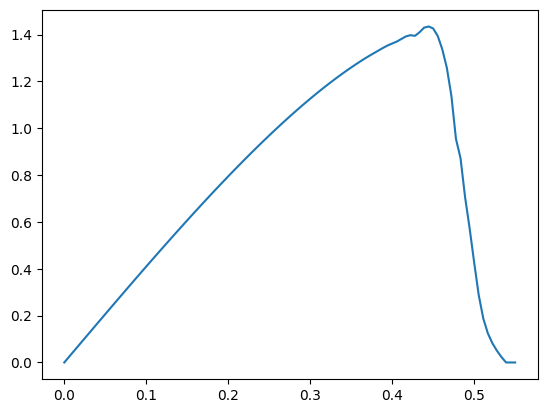

100%|██████████| 99/99 [06:34<00:00,  3.99s/it]


In [ ]:
#my_data = run_full_scan(temp = 0.45, phonon_scattering = 0.00, eta = 0.15, tc_rescaling = 1.0, current_amplitudes = np.linspace(0.0, 1.0, 1), dc_bias= 0.44)

#I_c = 37.3 * 8/10 # since the width changes
#R_DC = 165 * 10/8 
# DC_bias = 14.5 

my_data = run_full_scan(temp = 0.45, phonon_scattering = 0.00, eta = 0.10, tc_rescaling = 1.0, current_amplitudes = np.linspace(0.0,5.0, 50), dc_bias= 0.0)
my_data = run_full_scan(temp = 0.75, phonon_scattering = 0.00, eta = 0.10, tc_rescaling = 1.0, current_amplitudes = np.linspace(0.0,5.0, 50), dc_bias= 0.0)

#my_data = run_full_scan(temp = 0.45, phonon_scattering = 0.00, eta = 0.15, tc_rescaling = 1.0, current_amplitudes = np.linspace(1.0,1.0, 1), dc_bias= 14.5/(37.3 * 8/10))
#my_data = run_full_scan(temp = 0.45, phonon_scattering = 0.00, eta = 0.15, tc_rescaling = 1.0, current_amplitudes = np.linspace(1.0,1.0, 1), dc_bias= -14.5/(37.3 * 8/10))


100%|██████████| 1/1 [03:20<00:00, 200.34s/it]


T_c scaling is 0.83793104
[[1.4078044e+00]
 [1.3789361e+00]
 [1.3465807e+00]
 [1.3104262e+00]
 [1.2700977e+00]
 [1.2251362e+00]
 [1.1749721e+00]
 [1.1188487e+00]
 [1.0557975e+00]
 [9.8444235e-01]
 [9.0278500e-01]
 [8.0765945e-01]
 [6.9351113e-01]
 [5.4855949e-01]
 [3.3481672e-01]
 [2.0494539e-07]
 [2.0374351e-07]
 [2.0257025e-07]
 [2.0142431e-07]
 [2.0030441e-07]
 [1.9920935e-07]
 [1.9813807e-07]
 [1.9708951e-07]
 [1.9606271e-07]
 [1.9505680e-07]
 [1.9407092e-07]
 [1.9310430e-07]
 [1.9215616e-07]
 [1.9122584e-07]
 [1.9031263e-07]]


100%|██████████| 100/100 [14:59<00:00,  9.00s/it]


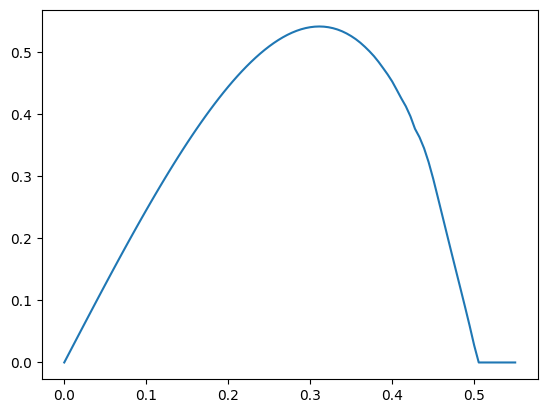

100%|██████████| 99/99 [06:13<00:00,  3.77s/it] 


In [ ]:
my_data = run_full_scan(temp = 0.75, phonon_scattering = 0.00, eta = 0.15, tc_rescaling = 1.0, current_amplitudes = np.linspace(0.0,5.0, 40), dc_bias= 0.0, filename = 'dense_q_scan_highT.dat')


100%|██████████| 1/1 [02:12<00:00, 132.46s/it]


T_c scaling is 0.83793104
[[1.4078044e+00]
 [1.3789361e+00]
 [1.3465807e+00]
 [1.3104262e+00]
 [1.2700977e+00]
 [1.2251362e+00]
 [1.1749721e+00]
 [1.1188487e+00]
 [1.0557975e+00]
 [9.8444235e-01]
 [9.0278500e-01]
 [8.0765945e-01]
 [6.9351113e-01]
 [5.4855949e-01]
 [3.3481672e-01]
 [2.0494539e-07]
 [2.0374351e-07]
 [2.0257025e-07]
 [2.0142431e-07]
 [2.0030441e-07]
 [1.9920935e-07]
 [1.9813807e-07]
 [1.9708951e-07]
 [1.9606271e-07]
 [1.9505680e-07]
 [1.9407092e-07]
 [1.9310430e-07]
 [1.9215616e-07]
 [1.9122584e-07]
 [1.9031263e-07]]


100%|██████████| 30/30 [04:47<00:00,  9.60s/it]


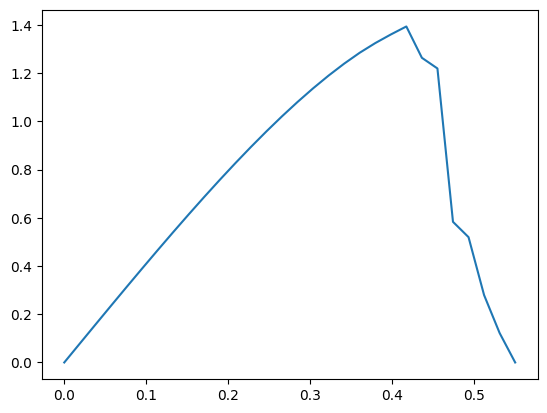

100%|██████████| 799/799 [21:17<00:00,  1.60s/it] 


In [7]:
#my_data = run_full_scan(temp = 0.45, phonon_scattering = 0.00, eta = 0.15, tc_rescaling = 1.0, current_amplitudes = np.linspace(1.0,1.0, 1), dc_bias= 14.5/(37.3 * 8/10))
my_data = run_full_scan(temp = 0.45, phonon_scattering = 0.00, eta = 0.15, tc_rescaling = 1.0, current_amplitudes = np.linspace(1.0,1.0, 1), dc_bias= -14.5/(37.3 * 8/10))


dict_keys(['t_scan_T_c_scaling', 't_scan_gaps', 'q_scan_gaps', 'q_scan_currents', 'q_scan_Qs', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])
1.3930243
(1, 100)
(1, 100)
[Array(0.95238084, dtype=float32)]
0.41904756


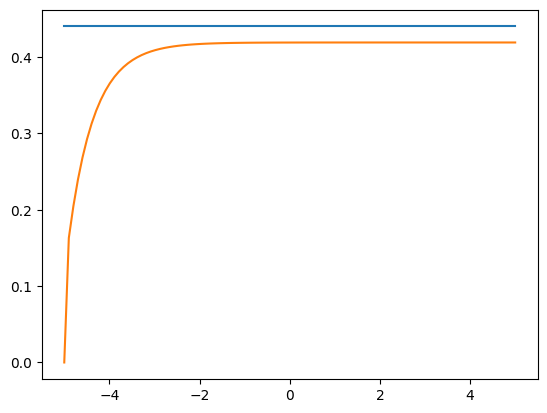

In [ ]:
print(my_data.keys())
print(my_data['q_scan_current_max'])
times = my_data['times'][0]


In [ ]:
crt_out = my_data['current_vs_time']
crt_int = my_data['pulse_in']
print(np.shape(crt_out))
print(np.shape(crt_int))
plt.plot(times,np.array(crt_int)[0,:])
plt.plot(times,np.array(crt_out)[0,:])
print(my_data['transmitivity'])
print(np.max(crt_out))

## Run $T_c$ rescaling procedure scan

In [4]:
cutoff = 30 * usadel.UsadelEvolution.get_bcs_ratio()
nw = 1500
eta = 0.1
grid_parameters = {'omega_sampling': nw, 'cutoff': cutoff, 'time_duration': 5.0, 'time_sampling': 100}
optimization_parameters = {'custom_jac': False, 'tol': 1e-3, 'maxiter': 50}
sigma_scatterings = {'Phonon': 1.0} # {'Dynes': 0.0, 'Elastic': 0.0}
sigma_scatterings = None

In [6]:
temp_list = jnp.linspace(0.1, 1.2, 20)
Q_list = jnp.linspace(0.0,0.7,1)

In [ ]:
gap_list = []

for temp in tqdm(temp_list):
    system_parameters = {'critical_temperature': 1.0, 'current_maximum': 1.0, 'temperature': temp, 'z_t/R_n': 50/150, 'eta': eta}

    crt_gap, _ = comp.calculate_equilibrium([temp], grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)
    gap_list += [crt_gap]

  0%|          | 0/20 [00:00<?, ?it/s]

 10%|█         | 2/20 [00:34<05:50, 19.46s/it]

In [ ]:
gap_list,  = comp.calculate_equilibrium(temp_list, grid_parameters, system_parameters, optimization_parameters = optimization_parameters, sigma_scatterings = sigma_scatterings,  Q_list = Q_list)


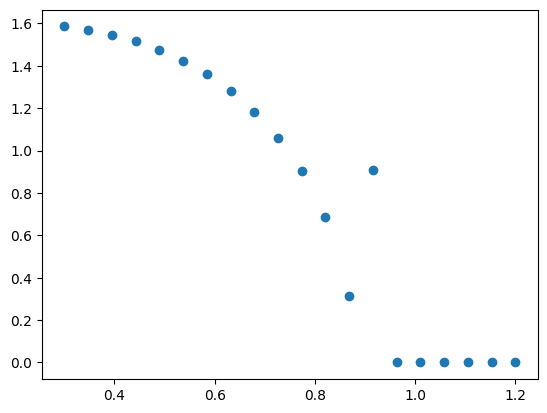

In [ ]:
plt.scatter(temp_list,np.array(gap_list)[:,0,0])

## Load and plot

In [4]:
def load_file(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data


In [5]:
def save_data(data, filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'wb') as output:  # Overwrites any existing file.
        pickle.dump(data, output)
        
def load_data(filename, data_path = '/home/filip/Documents/Research/Superconducting_vortices/Results/'):
    with open(data_path + filename, 'rb') as input:
        data = pickle.load(input)
    return data


def import_data_from_txt(file_name):
    # Read the title line
    with open(file_name, 'r') as f:
        title = f.readline().strip()

    # Read the data
    data = np.loadtxt(file_name, skiprows=1)
    print(np.shape(data))
    if np.shape(data)[1] == 2:
        # Split the data into two columns
        x = data[:, 0]
        y = data[:, 1]
    else:
        # Assume the data is already in two columns
        x = data[:, 1]
        y = data[:, -1]

    return title, data[:, 0], data[:, 1],data[:, 2], data[:, 3]


In [8]:
import numpy as np
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3


eta_list = [0.2]
temp_list = [0.45]
phonon_scattering_list = [0.0]
labels = []
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + '-2.pkl'
            data_theory_dictionaries += [load_file(filename)]
            labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(99, 4)
dict_keys(['q_scan_gaps', 'q_scan_currents', 'q_scan_current_max', 'times', 'pulse_in', 'current_vs_time', 'gap_vs_time', 'q_vs_time', 'transmitivity', 'current_inside'])


In [9]:
index = 8
plt.plot(my_data['times'][index], my_data['pulse_in'][index], color = 'dodgerblue', linewidth = 2.5)
plt.plot(my_data['times'][index], my_data['current_vs_time'][index], color = 'firebrick', linewidth = 2.5)


NameError: name 'my_data' is not defined

/tmp/ipykernel_7545/3928375042.py:8: RuntimeWarning: invalid value encountered in divide
  axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)


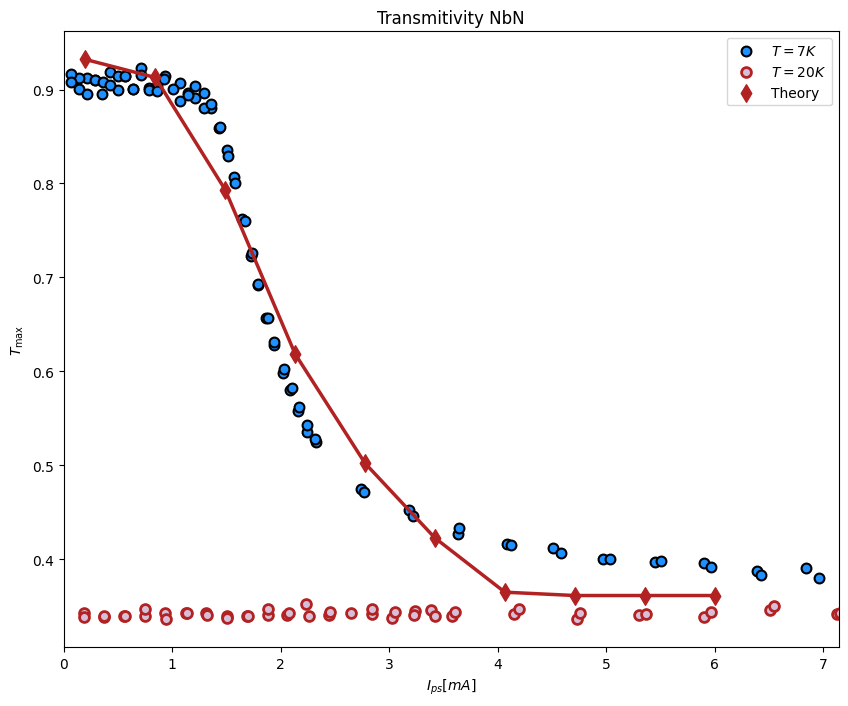

In [12]:

I_c = 35
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c/sc_data_y, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = 0
crt_dict = data_theory_dictionaries[index ]
#crt_dict = my_data
axs.scatter(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory')
axs.plot(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)


#plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

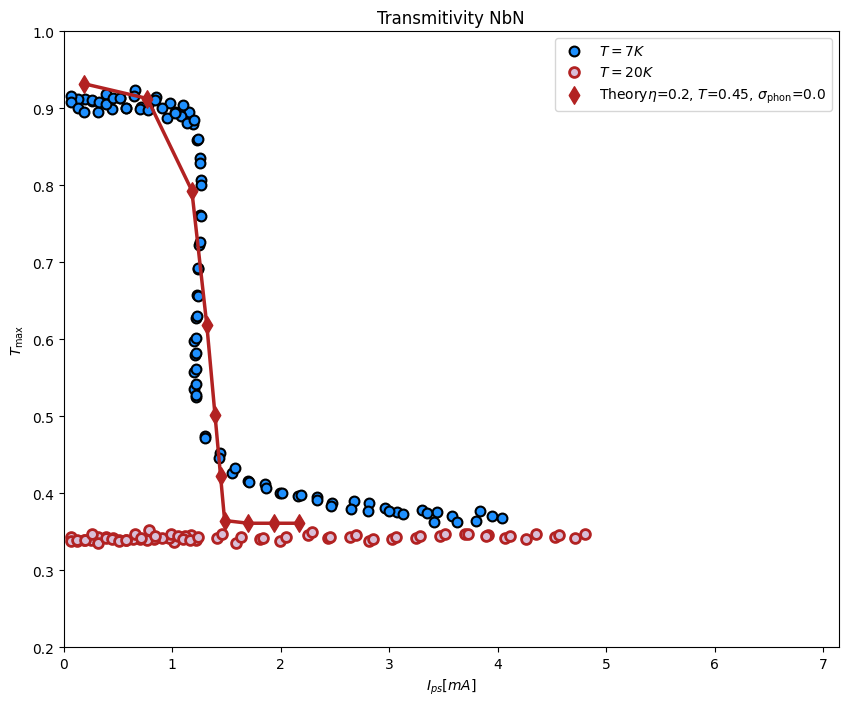

In [13]:


I_c = 35
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

plt.ylim(0.2, 1)
plt.xlim(0,170/I_c)


index = 0
crt_dict = data_theory_dictionaries[index ]
axs.scatter(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1) * jnp.array(crt_dict['transmitivity']),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1) * jnp.array(crt_dict['transmitivity']),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)

plt.ylim(0.2, 1)
plt.xlim(0,250/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')


## playing with lowpass filters

In [14]:
import numpy as np
title, data_1,data_2,data_3,data_4 = import_data_from_txt('/home/filip/Documents/Research/Superconducting_vortices/experimental_data/NbN data_7K_20K.txt')

normal_data_y = data_1
sc_data_y = data_2
normal_data_x = data_4
sc_data_x = data_3

eta_list = [0.05]
eta_list = [0.05]
temp_list = [0.45]
phonon_scattering_list = [0.1,0.2,0.3]
labels = []
data_theory_dictionaries = []
for eta in eta_list:
    for temp in temp_list:
        for phonon_scattering in phonon_scattering_list:
            filename = 'Quasi-static-evolution-T:' + str(np.round(temp,2)) + ' phonons:' + str(np.round(phonon_scattering,2)) + ' eta:' + str(np.round(eta,2)) + '-2.pkl'
            data_theory_dictionaries += [load_file(filename)]
            labels += [r'$\eta$=' + str(np.round(eta,2)) + r', $T$=' + str(np.round(temp,2)) + r', $\sigma_{\rm phon}$=' + str(np.round(phonon_scattering,2))]

print(data_theory_dictionaries[0].keys())

(99, 4)


FileNotFoundError: [Errno 2] No such file or directory: '/home/filip/Documents/Research/Superconducting_vortices/Keldysh-non-eq/psBQP/Quasi-static-evolution-T:0.45 phonons:0.1 eta:0.05-2.pkl'

In [15]:
from scipy import signal

def lowpass_filter(t, f_t, cutoff_freq, filter_order=5, method='butter'):
    """
    Apply a low-pass filter to a time-domain signal, removing frequencies above cutoff.

    Parameters:
    -----------
    t : array_like
        Time array (must be evenly spaced)
    f_t : array_like
        Function values at time points t
    cutoff_freq : float
        Cutoff frequency in Hz (frequencies above this will be filtered out)
    filter_order : int, optional
        Order of the Butterworth filter (default: 5)
    method : str, optional
        Filter method: 'butter' for Butterworth (default), 'fft' for FFT-based

    Returns:
    --------
    f_filtered : ndarray
        Filtered signal
    """

    if method == 'butter':
        # Calculate sampling frequency
        dt = t[1] - t[0]
        fs = 1.0 / dt

        # Normalize cutoff frequency (Nyquist frequency = fs/2)
        nyquist = fs / 2.0
        normalized_cutoff = cutoff_freq / nyquist

        if normalized_cutoff >= 1.0:
            raise ValueError(f"Cutoff frequency {cutoff_freq} Hz exceeds Nyquist frequency {nyquist} Hz")

        # Design Butterworth low-pass filter
        b, a = signal.butter(filter_order, normalized_cutoff, btype='low', analog=False)

        # Apply filter
        f_filtered = signal.filtfilt(b, a, f_t)

    elif method == 'fft':
        # FFT-based filtering
        N = len(f_t)
        dt = t[1] - t[0]

        # Compute FFT
        f_fft = np.fft.fft(f_t)
        freqs = np.fft.fftfreq(N, dt)

        # Create low-pass filter mask
        filter_mask = np.abs(freqs) <= cutoff_freq

        # Apply filter in frequency domain
        f_fft_filtered = f_fft * filter_mask

        # Inverse FFT to get filtered signal
        f_filtered = np.fft.ifft(f_fft_filtered).real

    else:
        raise ValueError(f"Unknown method '{method}'. Use 'butter' or 'fft'")

    return f_filtered


In [16]:
data_index = 0

times = data_theory_dictionaries[data_index]['times'][-1]
data_x = data_theory_dictionaries[data_index]['pulse_in']
data_y = data_theory_dictionaries[data_index]['current_vs_time']
index = 5

filter_scale = 1.0

data_x = data_x[index]
data_y = data_y[index]

plt.plot(times, data_x, label = r'$I_{IN}(t)$')
plt.plot(times, data_y, label = r'$I(t)$')


filtered_data_x = lowpass_filter(times, data_x,  0.7 / 0.31 * filter_scale, method= 'fft')
filtered_data_y = lowpass_filter(times, data_y,  0.7 / 0.31 * filter_scale, method= 'fft')

plt.plot(times, filtered_data_x, label = r'$I_{IN}(t) filt$')
plt.plot(times, filtered_data_y, label = r'$I(t) filt$')

plt.legend()

filtered_pulse_in = []
filtered_transmitivity = []

for index in range(len(data_theory_dictionaries[data_index]['pulse_in'])):
    times = data_theory_dictionaries[data_index]['times'][-1]
    data_x = data_theory_dictionaries[data_index]['pulse_in']
    data_y = data_theory_dictionaries[data_index]['current_vs_time']
    data_x = data_x[index]
    data_y = data_y[index]

    filtered_data_x = lowpass_filter(times, data_x,  0.7 / 0.31 * filter_scale,method= 'fft')
    filtered_data_y = lowpass_filter(times, data_y, 0.7 / 0.31 * filter_scale,method= 'fft')

    filtered_pulse_in += [np.max(filtered_data_x)]
    filtered_transmitivity += [np.max(filtered_data_y) / np.max(filtered_data_x)]


print(filtered_pulse_in)
print(filtered_transmitivity)

IndexError: list index out of range

/tmp/ipykernel_7545/1431980396.py:8: RuntimeWarning: invalid value encountered in divide
  axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)


IndexError: list index out of range

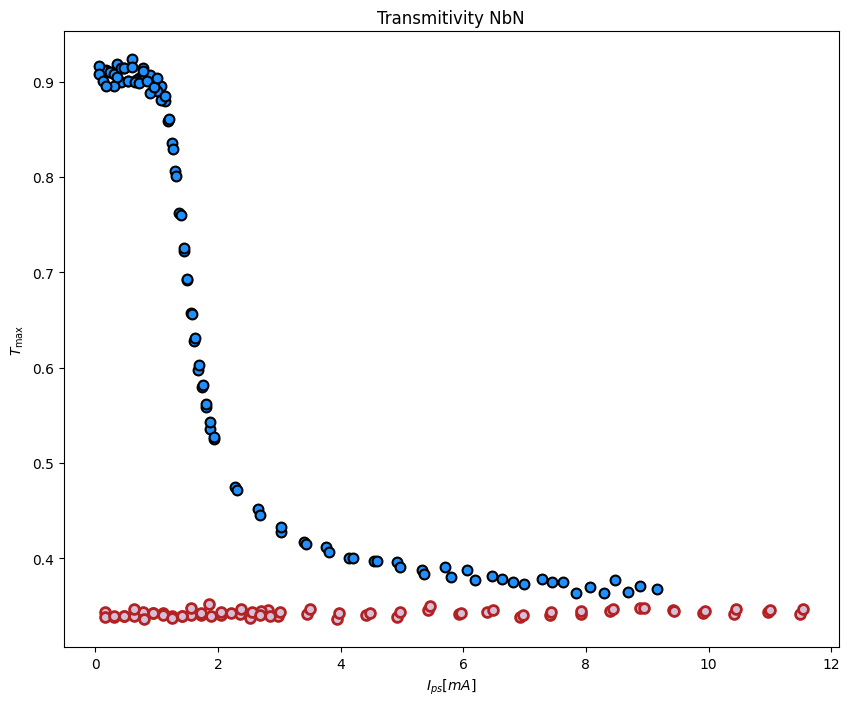

In [17]:

I_c = 42
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c/sc_data_y, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c/normal_data_y, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = data_index
crt_dict = data_theory_dictionaries[index ]
axs.scatter(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)

axs.scatter(filtered_pulse_in, filtered_transmitivity, marker = 'd', color = 'teal', s = 80, label = r'Theory-filtered' + labels[index])
axs.plot(filtered_pulse_in, filtered_transmitivity, color = 'teal', linewidth = 2.5)

plt.ylim(0.2, 1)
plt.xlim(0,350/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')

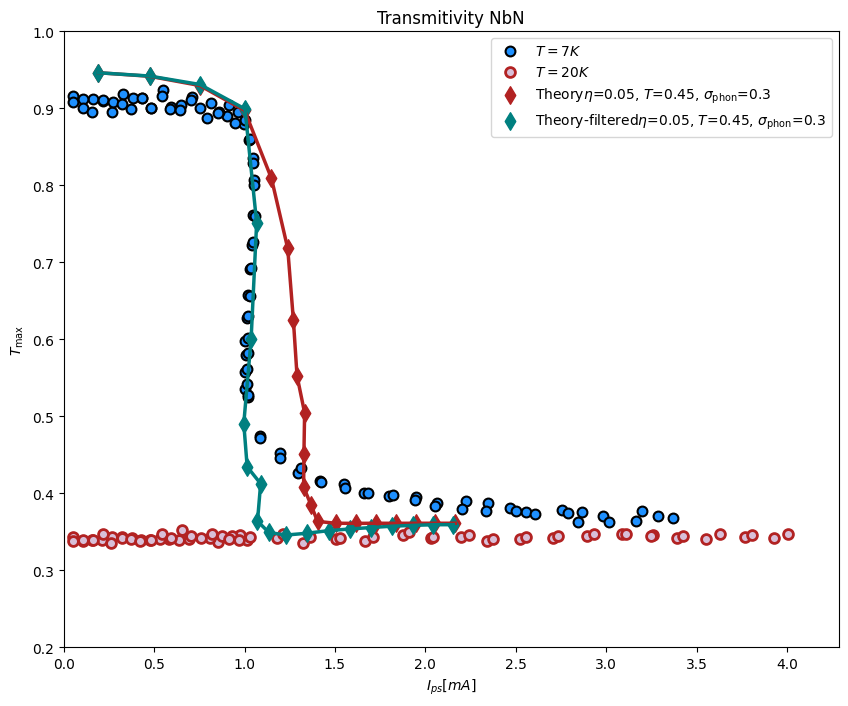

In [ ]:

I_c = 42
fig, axs = plt.subplots(1,1,figsize = (10,8))
axs.set_ylabel(r'$T_{\rm max}$')
axs.set_xlabel(r'$I_{ps}[mA]$')
axs.set_title(r'Transmitivity NbN')

axs.scatter(np.abs(sc_data_x)/I_c, sc_data_y, color = 'dodgerblue', marker = 'o',label = r'$T = 7K$', edgecolors='black', s = 50, linewidth = 1.5)
axs.scatter(np.abs(normal_data_x)/I_c, normal_data_y, color = 'thistle', marker = 'o',label =  r'$T = 20K$', edgecolors='firebrick', s = 50, linewidth = 2)

index = data_index
crt_dict = data_theory_dictionaries[index ]
axs.scatter(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1) * jnp.array(crt_dict['transmitivity']),crt_dict['transmitivity'], marker = 'd', color = 'firebrick', s = 80, label = r'Theory' + labels[index])
axs.plot(jnp.max(jnp.array(crt_dict['pulse_in']), axis = 1) * jnp.array(crt_dict['transmitivity']),crt_dict['transmitivity'], color = 'firebrick', linewidth = 2.5)

axs.scatter(np.array(filtered_pulse_in) * np.array(filtered_transmitivity), filtered_transmitivity, marker = 'd', color = 'teal', s = 80, label = r'Theory-filtered' + labels[index])
axs.plot(np.array(filtered_pulse_in) * np.array(filtered_transmitivity), filtered_transmitivity, color = 'teal', linewidth = 2.5)

plt.ylim(0.2, 1)
plt.xlim(0,180/I_c)

plt.legend()
#plt.savefig('Dirty supercondutor-large eta-T vs I_in')